# Credit Card Fraud Detection — EDA & Modeling

Real transaction data (Sep 2013, European cardholders), 284,807 transactions, 492 labeled fraud (~0.17%).

This notebook walks through the exploratory analysis and reuses the `fraud_detection` package (see `src/`) for the actual modeling pipeline, so the logic lives in one tested place instead of being duplicated here.

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_detection.config import RAW_DATA_PATH
from fraud_detection.data import load_data, load_train_test_split
from fraud_detection.features import add_hour_feature, PCA_COLUMNS

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

/home/jigoku/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load & inspect

In [2]:
df = load_data()
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print('missing values per column:')
print(df.isna().sum().sum(), 'total')
print()
print('duplicate rows:', df.duplicated().sum())
df.describe().T

missing values per column:
0 total



duplicate rows: 1081


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2. Class imbalance

This is the single most important fact about this dataset: **fraud is 0.173% of transactions**. A model that never flags anything is 99.8% "accurate" and completely useless — accuracy is not going to be our metric of choice anywhere in this notebook.

Class
0    284315
1       492
Name: count, dtype: int64
fraud rate: 0.1727%


/tmp/ipykernel_548130/2831674414.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_548130/2831674414.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legit', 'Fraud'])


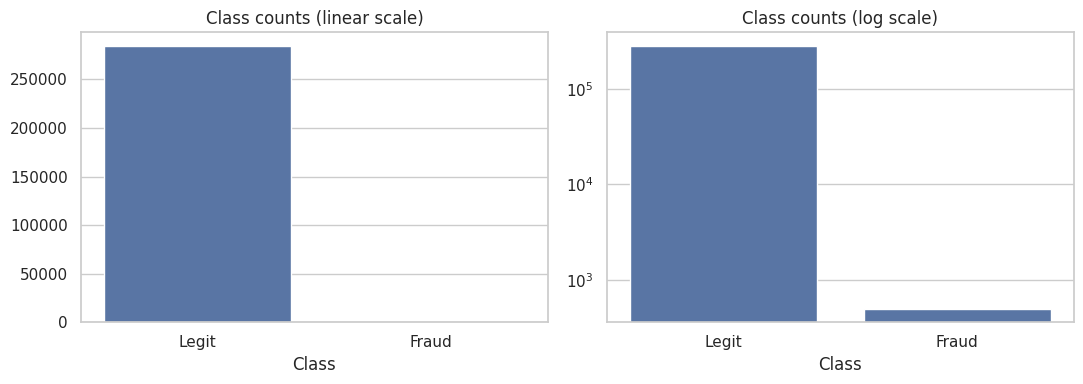

In [4]:
counts = df['Class'].value_counts()
print(counts)
print(f"fraud rate: {df['Class'].mean():.4%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=counts.index, y=counts.values, ax=axes[0])
axes[0].set_xticklabels(['Legit', 'Fraud'])
axes[0].set_title('Class counts (linear scale)')
sns.barplot(x=counts.index, y=counts.values, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Legit', 'Fraud'])
axes[1].set_title('Class counts (log scale)')
plt.tight_layout()

## 3. Transaction amount by class

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


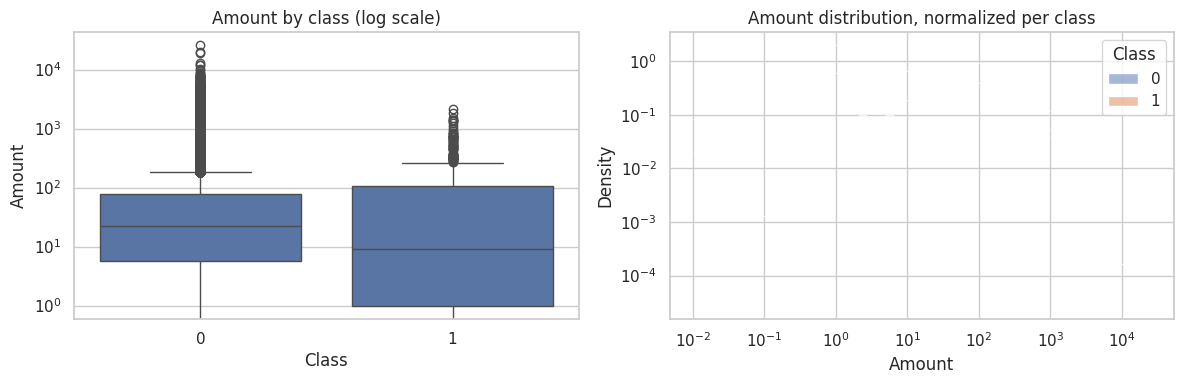

In [5]:
print(df.groupby('Class')['Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Amount by class (log scale)')
sns.histplot(data=df, x='Amount', hue='Class', bins=50, log_scale=(True, True),
             stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Amount distribution, normalized per class')
plt.tight_layout()

Fraudulent transactions skew toward smaller amounts on average, but with real spread — amount alone is a weak signal, consistent with it being just one of ~30 features.

## 4. Time-of-day pattern

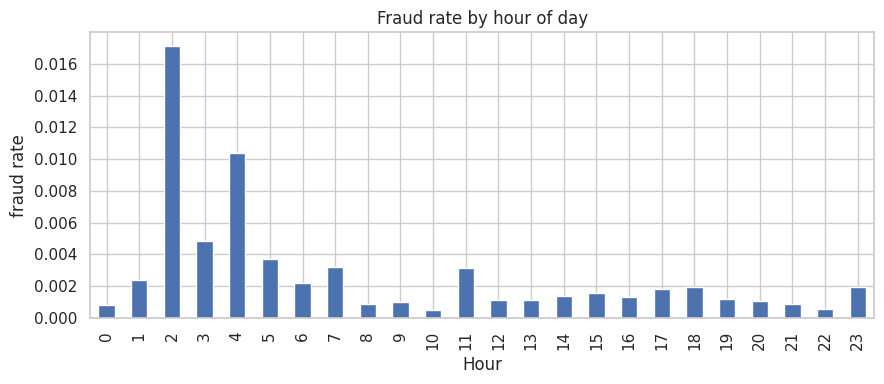

In [6]:
df_hour = add_hour_feature(df)

fig, ax = plt.subplots(figsize=(9, 4))
rate_by_hour = df_hour.groupby('Hour')['Class'].mean()
rate_by_hour.plot(kind='bar', ax=ax)
ax.set_ylabel('fraud rate')
ax.set_title('Fraud rate by hour of day')
plt.tight_layout()

Fraud rate is markedly higher in the early-morning hours, when legitimate transaction volume is at its lowest — the *rate* spikes even though the raw *count* of fraud doesn't. This is exactly the kind of signal that gets lost if you only look at raw `Time` instead of deriving hour-of-day.

## 5. Correlation of PCA components with the target

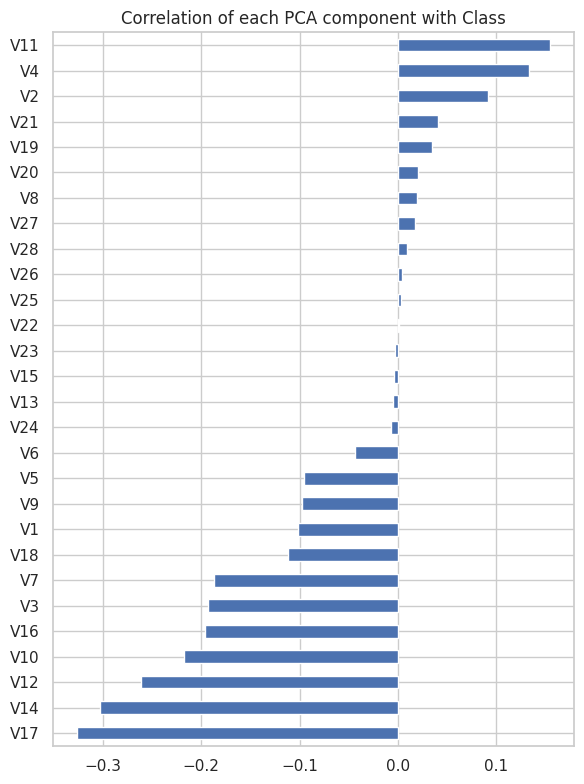

In [7]:
corr_with_target = df[PCA_COLUMNS + ['Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
corr_with_target.plot.barh(ax=ax)
ax.set_title('Correlation of each PCA component with Class')
plt.tight_layout()

A handful of components (e.g. V17, V14, V12, V10, V4, V11) stand out — expect these to dominate feature importance in the tree-based models below.

## 6. Modeling

Reusing `fraud_detection.train` so the CV/threshold-tuning/evaluation logic isn't duplicated between the notebook and the CLI entry point — this cell runs the exact same code `python -m fraud_detection.train` runs.

In [8]:
from fraud_detection import train as train_module

X_train, X_test, y_train, y_test = load_train_test_split()
print(f'train: {len(X_train)} rows ({y_train.sum()} fraud)')
print(f'test:  {len(X_test)} rows ({y_test.sum()} fraud)')

models = train_module.get_models(y_train)
cv_results = train_module.cross_validate_models(X_train, y_train, models)
cv_results

train: 227845 rows (394 fraud)
test:  56962 rows (98 fraud)


  logistic_regression: PR-AUC 0.7513 +/- 0.0246 (8.0s)


  random_forest: PR-AUC 0.8408 +/- 0.0152 (25.9s)


  xgboost: PR-AUC 0.8418 +/- 0.0175 (4.2s)


,cv_pr_auc_mean,cv_pr_auc_std
xgboost,0.841753,0.017510
random_forest,0.840785,0.015199
logistic_regression,0.751285,0.024634


In [9]:
from fraud_detection.evaluate import compute_metrics, metrics_to_dataframe, plot_pr_curve, plot_roc_curve, plot_confusion_matrix

fitted, test_metrics, test_probas = {}, {}, {}
for name, model in models.items():
    pipe = train_module.make_pipeline(model)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    test_probas[name] = proba
    test_metrics[name] = compute_metrics(y_test, (proba >= 0.5).astype(int), proba)

metrics_df = metrics_to_dataframe(test_metrics)
metrics_df.insert(0, 'cv_pr_auc_mean', cv_results['cv_pr_auc_mean'])
metrics_df[['cv_pr_auc_mean', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1']].round(4)

,cv_pr_auc_mean,pr_auc,roc_auc,precision,recall,f1
xgboost,0.8418,0.8761,0.9741,0.8367,0.8367,0.8367
random_forest,0.8408,0.8450,0.9824,0.8696,0.8163,0.8421
logistic_regression,0.7513,0.7236,0.9738,0.0558,0.9082,0.1051


best model by CV PR-AUC: xgboost


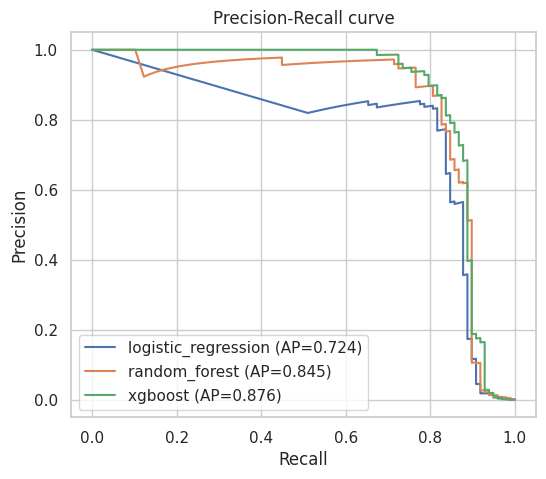

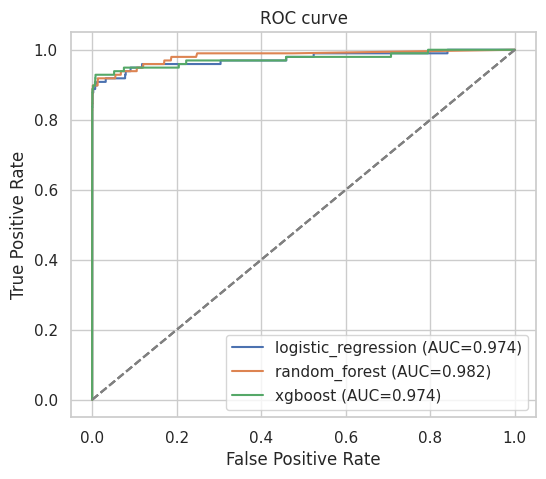

In [10]:
best_name = cv_results.index[0]
print('best model by CV PR-AUC:', best_name)

fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in test_probas.items():
    plot_pr_curve(y_test, proba, label=name, ax=ax)

fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in test_probas.items():
    plot_roc_curve(y_test, proba, label=name, ax=ax)

## 7. Threshold tuning

The first version of this analysis tuned the threshold on a single 80/20 train/val split. That turned out to be a mistake worth keeping in the notebook as a lesson: with only ~400 fraud examples in the training set, a 20% validation slice has ~80 positives to tune against, which is few enough that the "optimal" threshold it picks is noisy — it actually scored *worse* on the test set than the untuned 0.5 default.

Fix: use 3-fold **out-of-fold** predictions across the entire training set (`cross_val_predict`) instead of one split. That uses all ~400 positives instead of ~80, without ever touching the test set.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from fraud_detection.evaluate import find_best_threshold_by_cost
from fraud_detection.config import RANDOM_STATE

cv_proba = cross_val_predict(
    train_module.make_pipeline(train_module.get_models(y_train)[best_name]),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba',
)[:, 1]

# illustrative cost matrix: a missed fraud costs ~100x a false alarm.
# swap in real business numbers before trusting this in production.
threshold = find_best_threshold_by_cost(y_train, cv_proba, cost_fp=1.0, cost_fn=100.0)
print(f'tuned threshold: {threshold:.4f} (default is 0.5)')

best_pred = (test_probas[best_name] >= threshold).astype(int)
final_metrics = compute_metrics(y_test, best_pred, test_probas[best_name])
final_metrics

tuned threshold: 0.0118 (default is 0.5)


{'precision': 0.18200408997955012,
 'recall': 0.9081632653061225,
 'f1': 0.303236797274276,
 'roc_auc': 0.9740508682369965,
 'pr_auc': 0.8760723391288635,
 'true_positives': 89,
 'false_positives': 400,
 'false_negatives': 9,
 'true_negatives': 56464}

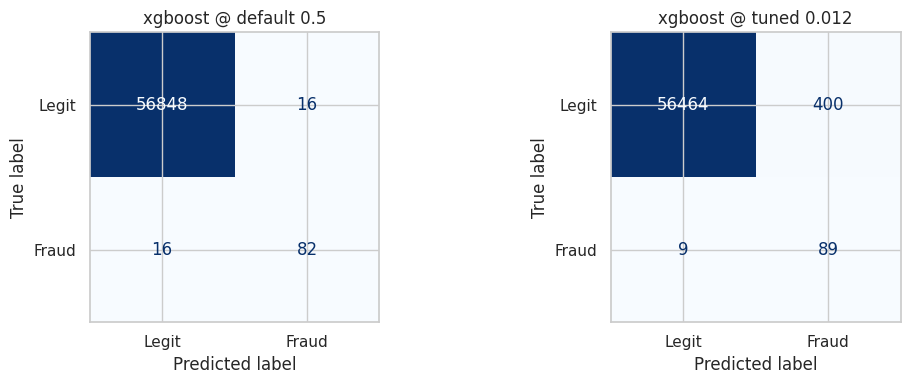

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_test, (test_probas[best_name] >= 0.5).astype(int),
                       title=f'{best_name} @ default 0.5', ax=axes[0])
plot_confusion_matrix(y_test, best_pred,
                       title=f'{best_name} @ tuned {threshold:.3f}', ax=axes[1])
plt.tight_layout()

## 8. Feature importance

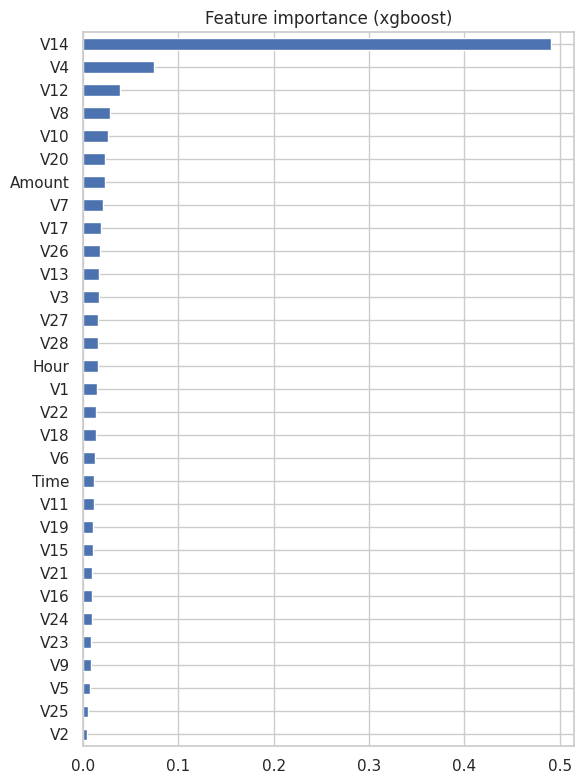

In [13]:
from fraud_detection.features import get_feature_names

best_clf = fitted[best_name].named_steps['clf']
if hasattr(best_clf, 'feature_importances_'):
    importances = pd.Series(best_clf.feature_importances_, index=get_feature_names()).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 8))
    importances.plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_title(f'Feature importance ({best_name})')
    plt.tight_layout()
else:
    print(f'{best_name} has no feature_importances_ (e.g. linear model — inspect coefficients instead)')

## 9. Takeaways

- With this level of class imbalance, **accuracy is meaningless**; PR-AUC and a cost-aware threshold are what actually reflect the business trade-off.
- Tree-based models (Random Forest / XGBoost) with class-imbalance handling clearly beat plain Logistic Regression on PR-AUC here — worth confirming that holds on your own data before assuming it generalizes.
- The 0.5 default threshold is arbitrary; tuning it against an explicit cost matrix (missed fraud vs. false alarm) is what turns a ranking model into an actual decision rule, and it should be revisited whenever the cost assumptions change.
- This model would go stale: fraud patterns shift over time (concept drift), so a production version needs periodic retraining and drift monitoring, not a one-off fit.